In [1]:
import os,json,cortex
import numpy as np
from config.dir import DATA_DIR ,RESULTS_DATA_DIR
from sklearn.preprocessing import StandardScaler
from voxelwise_tutorials.delayer import Delayer
from himalaya.kernel_ridge import KernelRidgeCV
from himalaya.backend import set_backend
from sklearn.pipeline import make_pipeline
from voxelwise_tutorials.utils import generate_leave_one_run_out
from sklearn.model_selection import check_cv
import matplotlib.pyplot as plt
from utils.npp import zscore

# Using subjects 3 for 9-12 session as a training 

In [2]:
def open_json(subj,file):
    
    dir=os.path.join( RESULTS_DATA_DIR,subj)
    with open(os.path.join(dir,file), "r")  as f:
        data = json.load(f)
    return  np.array(data, dtype=float)

# Features using S3 fmri response for training & S3 predicted values for testing

In [3]:
subject_1 = 'sub-UTS03'
subject_2 = 'sub-UTS02'

X_train = open_json(subject_1,'fmri_train.json')
X_test= zscore(np.load(os.path.join(RESULTS_DATA_DIR,subject_1,'test_predict.npy')))

print("(n_samples_train, n_features) =", X_train.shape)
print("(n_samples_test, n_features) =", X_test.shape)

(n_samples_train, n_features) = (11414, 95556)
(n_samples_test, n_features) = (291, 95556)


In [4]:
print("Mean of features(train):",np.mean(X_train))
print("Standard deviation of features(train): ",np.std(X_train))
print("Mean of features(test) :",np.mean(X_test))
print("Standard deviation of features(test): ",np.std(X_test))

Mean of features(train): -6.404209986505114e-19
Standard deviation of features(train):  1.0
Mean of features(test) : -1.04664451297207e-18
Standard deviation of features(test):  1.0


# Selecting top 10k voxels for training

In [5]:
scores_train = np.load(os.path.join(RESULTS_DATA_DIR,subject_1,'scores_train.npy'))
scores_test = np.load(os.path.join(RESULTS_DATA_DIR,subject_1,'scores_test.npy'))
best_voxels = np.argsort(scores_train)[::-1][:10000]
X_train_best = X_train[:, best_voxels]
X_test_best = X_test[:, best_voxels]
print("(n_samples_train, n_features) =", X_train_best.shape)
print("(n_samples_test, n_features) =", X_test_best.shape)

(n_samples_train, n_features) = (11414, 10000)
(n_samples_test, n_features) = (291, 10000)


# Subject 2 fmri 

In [6]:
Y_train = open_json(subject_2,'fmri_train.json')
Y_test = zscore(open_json(subject_2,'fmri_test.json'))

print("(n_samples_train, n_voxels) =", Y_train.shape)
print("( n_samples_test, n_voxels) =", Y_test.shape)

(n_samples_train, n_voxels) = (11414, 94251)
( n_samples_test, n_voxels) = (291, 94251)


In [7]:
print("Mean of fmri(train):",np.mean(Y_train))
print("Standard deviation of fmri(train):",np.std(Y_train))
print("Mean of fmri(train):",np.mean(Y_test))
print("Standard deviation of fmri(train):",np.std(Y_test))

Mean of fmri(train): 1.163308154432966e-18
Standard deviation of fmri(train): 1.0
Mean of fmri(train): 3.1834090804837863e-18
Standard deviation of fmri(train): 1.0


# loading runon set for cv

In [8]:
run_onsets= open_json(subject_1,'run_on.json').tolist()
run_onsets=list(map(int, run_onsets))
len(run_onsets)

32

In [9]:
n_samples_train = X_train_best.shape[0]
cv = generate_leave_one_run_out(n_samples_train, run_onsets)
cv = check_cv(cv)  # copy the cross-validation splitter into a reusable list

In [10]:
X_train_= X_train_best.astype("float32")
alphas = np.logspace(1, 20, 20)

# Create training model pipline 

In [11]:
pipeline = make_pipeline(
    StandardScaler(with_mean=True, with_std=False),
    Delayer(delays=[1, 2, 3, 4]),
    KernelRidgeCV(
        alphas=alphas, cv=cv,
        solver_params=dict(n_targets_batch=500, n_alphas_batch=5,
                           n_targets_batch_refit=100)),
)

In [12]:
backend = set_backend("torch_cuda", on_error="warn")
print(backend)

<module 'himalaya.backend.torch_cuda' from '/home/ckj24/miniforge-pypy3/envs/fmri-algo/lib/python3.13/site-packages/himalaya/backend/torch_cuda.py'>


In [13]:
_ = pipeline.fit(X_train_best, Y_train)

/home/ckj24/miniforge-pypy3/envs/fmri-algo/lib/python3.13/site-packages/himalaya/backend/_utils.py:138: UserWarning: GPU backend torch_cuda is much faster with single precision floats (float32), got input in torch.float64. Consider casting your data to float32.
  warnings.warn(


# Scores of training and testing data set

In [14]:
scores_train = pipeline.score(X_train_best, Y_train)
print("(n_voxels train,) =", scores_train.shape)
scores_test = pipeline.score(X_test_best, Y_test)
print("(n_voxels test,) =", scores_test.shape)

(n_voxels train,) = torch.Size([94251])
(n_voxels test,) = torch.Size([94251])


Text(0.5, 0, 'R-squared')

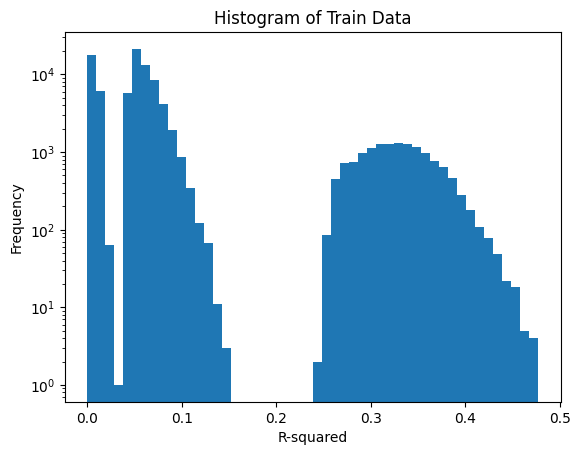

In [15]:
plt.hist(scores_train.cpu().numpy(), bins=50, log=True)
plt.title("Histogram of Train Data")
plt.ylabel("Frequency")
plt.xlabel("R-squared")

Text(0.5, 0, 'R-squared')

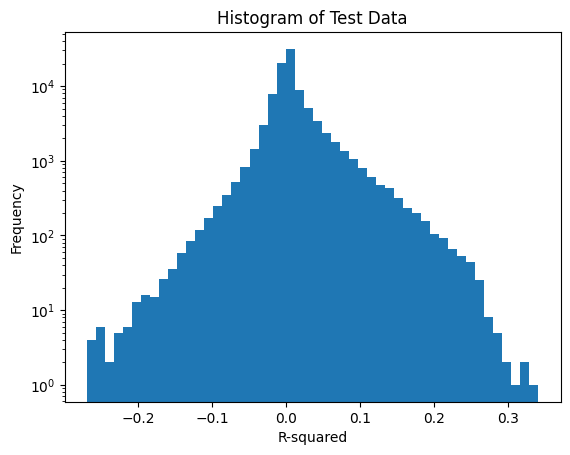

In [23]:
plt.hist(scores_test.cpu().numpy(), bins=50, log=True)
plt.title("Histogram of Test Data")
plt.ylabel("Frequency")
plt.xlabel("R-squared")

In [24]:
print("r-squared_average train =", np.mean(scores_train.cpu().numpy()).round(4))
print("r-squared_average =", np.mean(scores_test.cpu().numpy()).round(4))

r-squared_average train = 0.0864
r-squared_average = 0.0093


# Save trained data 

In [ ]:
#np.save(os.path.join(RESULTS_DATA_DIR,subject_2,'scores_test_transform_delay'), scores_test.cpu().numpy())

# plotting on pycortex

In [25]:
def set_pycortex_store(filestore):
    """Set the pycortex store to the specified directory."""
    cortex.database.default_filestore = filestore
    cortex.db.filestore = filestore
    cortex.db.reload_subjects()
    print(f"pycortex store set to {filestore}")


In [26]:
set_pycortex_store(os.path.join(DATA_DIR, 'ds003020/derivative/pycortex-db'))

pycortex store set to /home/ckj24/genevieve/ds003020/derivative/pycortex-db


# Training Data Subject 2

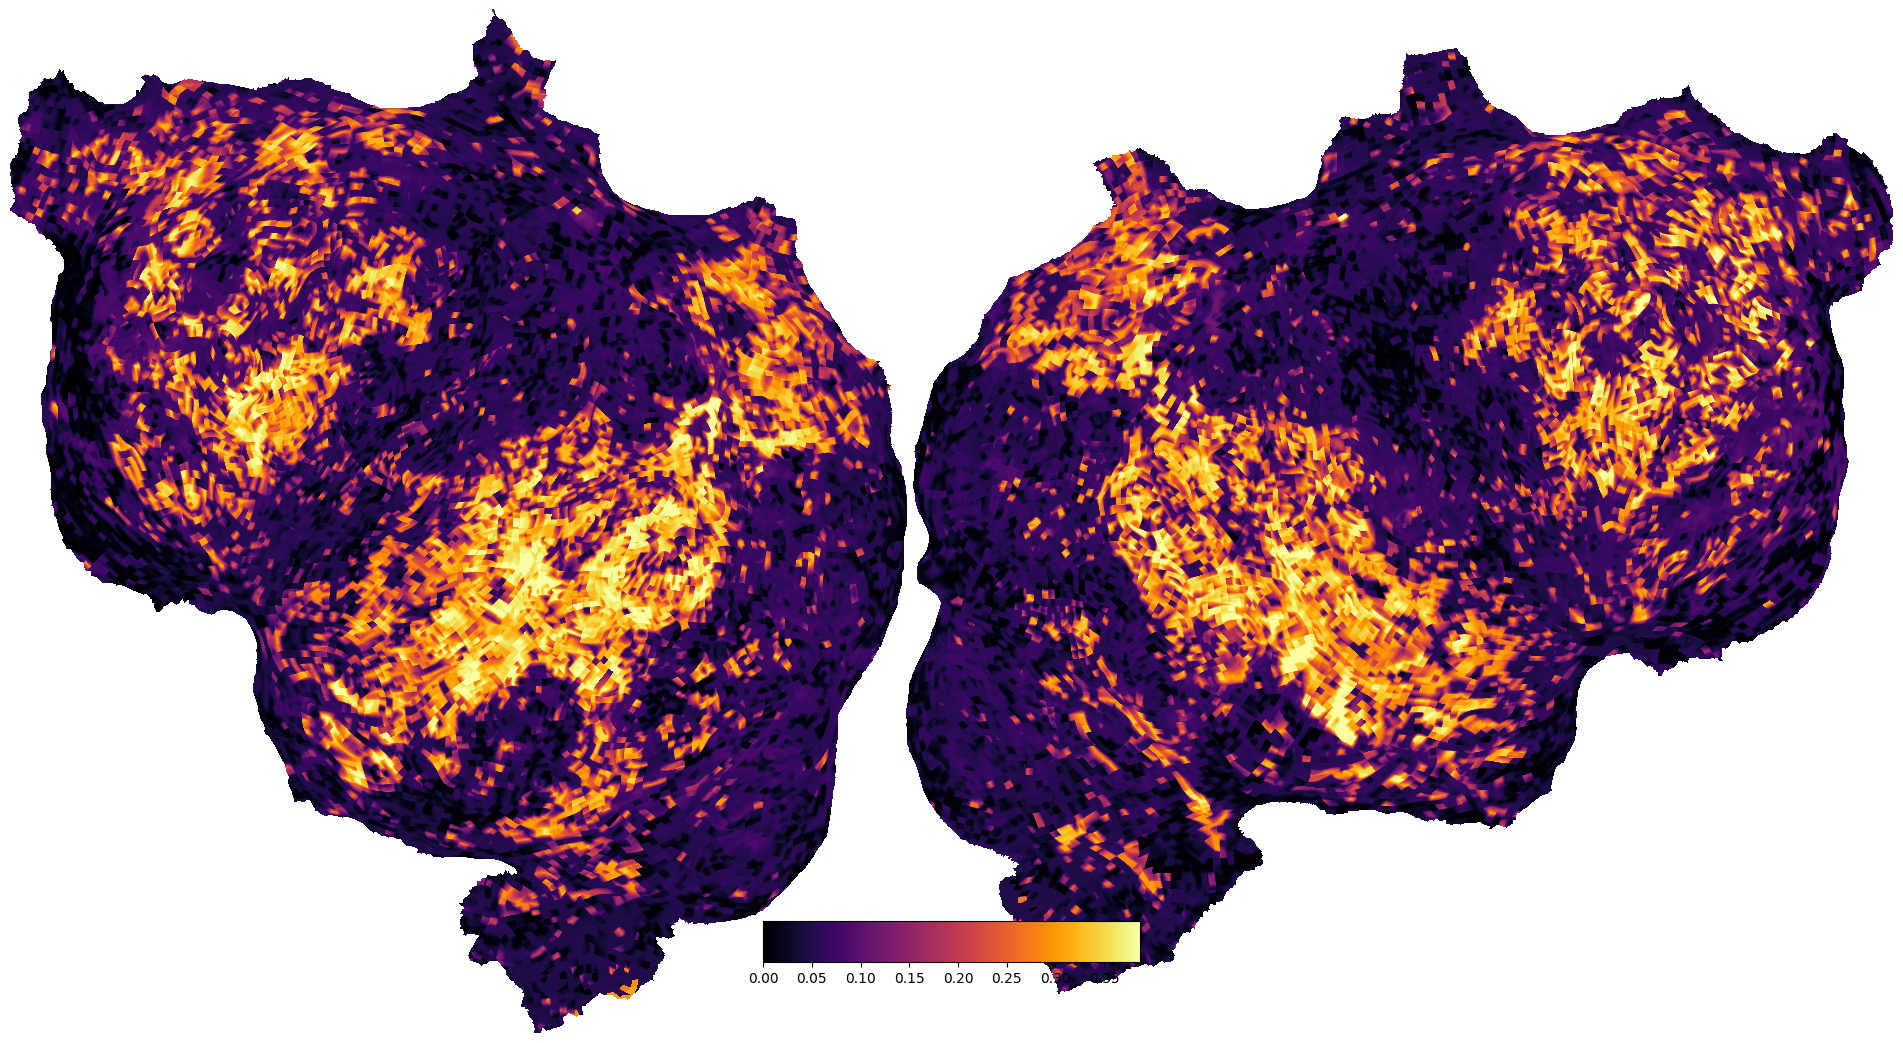

In [27]:
subject = 'UTS02'
xfm = 'UTS02_auto'

# First create example voxel data for this subject and transform
voxel_data = scores_train.cpu().numpy()
voxel_vol = cortex.Volume(voxel_data, subject, xfm,cmap="inferno")

# Then we have to get a mapper from voxels to vertices for this transform
mapper = cortex.get_mapper(subject, xfm, 'line_nearest', recache=True)

# Just pass the voxel data through the mapper to get vertex data
vertex_map = mapper(voxel_vol)

# You can plot both as you would normally plot Volume and Vertex data
cortex.quickshow(voxel_vol, with_rois=False)
plt.show()

# Testing Data for S2 

Caching mapper...


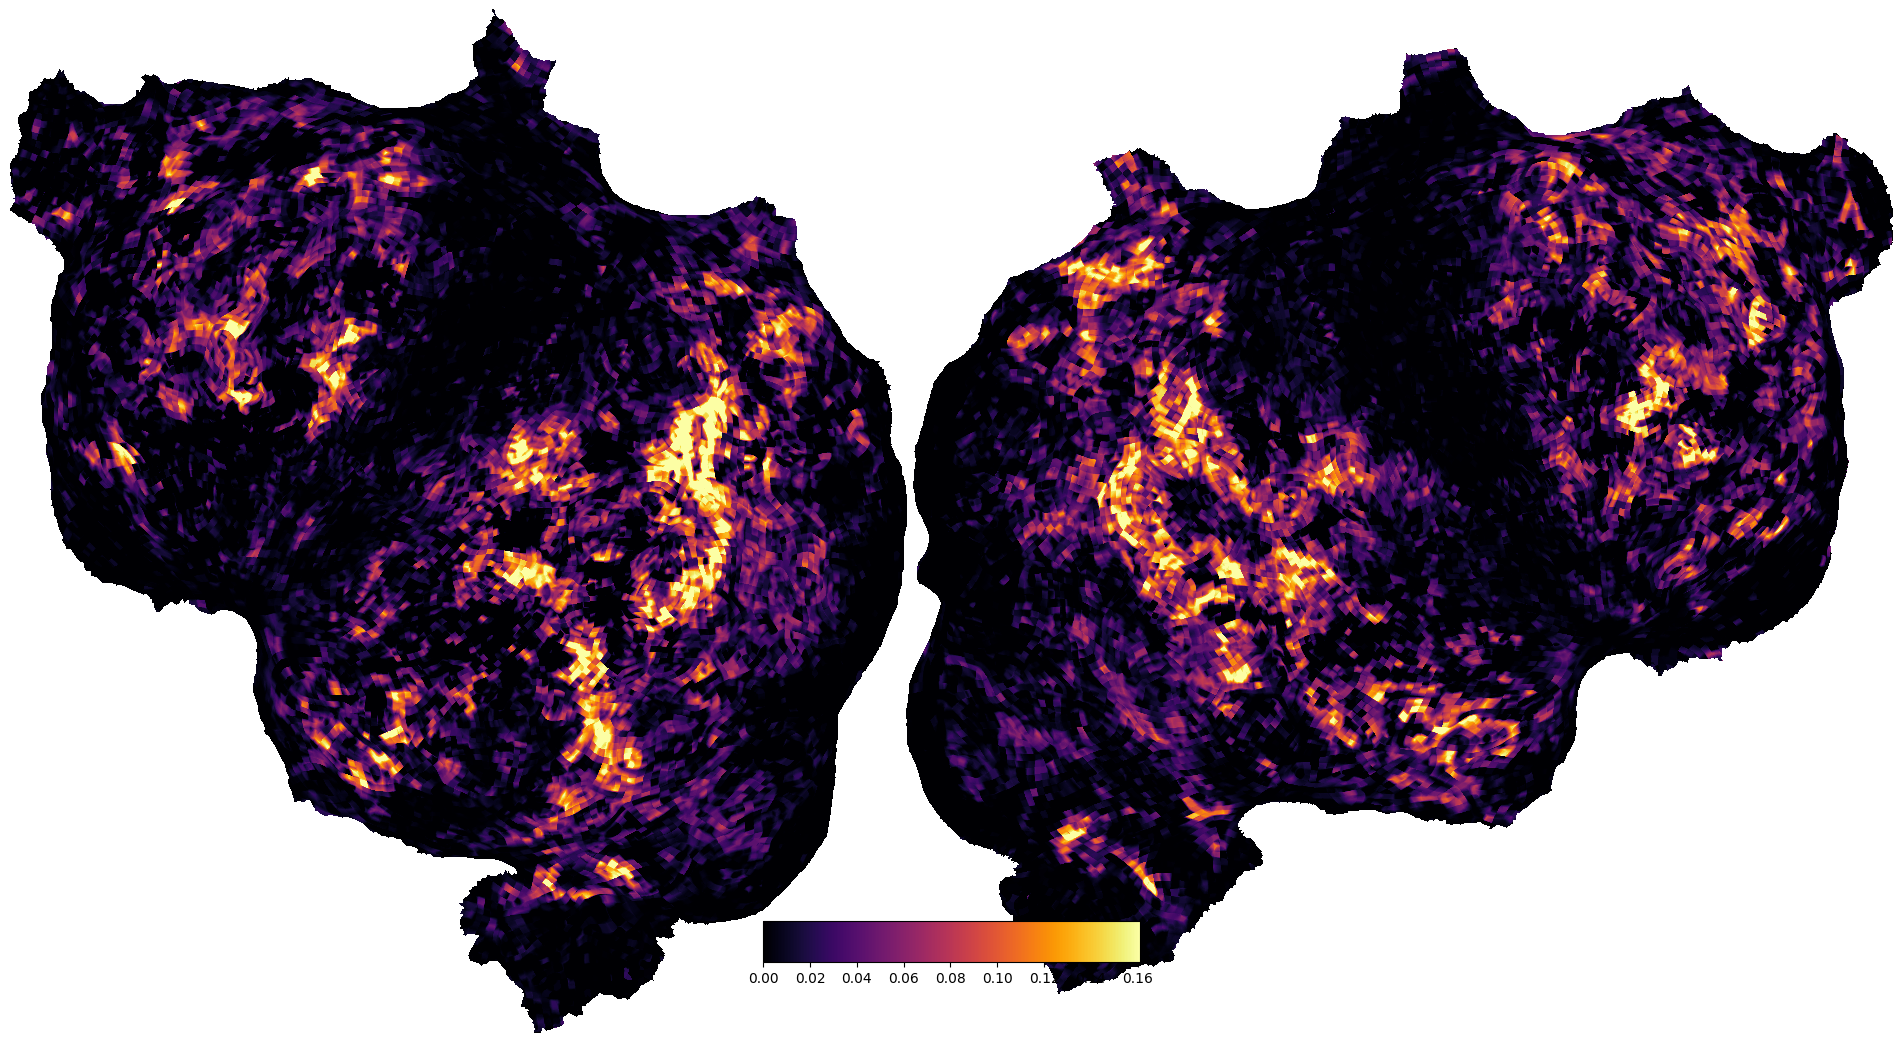

In [28]:
# First create example voxel data for this subject and transform
voxel_data = scores_test.cpu().numpy()
voxel_vol = cortex.Volume(voxel_data, subject, xfm,vmin=0,cmap="inferno")

# Then we have to get a mapper from voxels to vertices for this transform
mapper = cortex.get_mapper(subject, xfm,  recache=True)

# Just pass the voxel data through the mapper to get vertex data
vertex_map = mapper(voxel_vol)

# You can plot both as you would normally plot Volume and Vertex data
cortex.quickshow(voxel_vol, with_rois=False)
plt.show()

<Axes: xlabel='log10(alpha)', ylabel='Number of targets'>

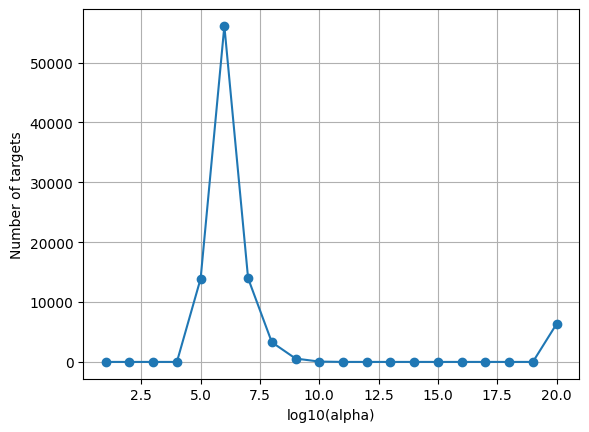

In [29]:
from himalaya.viz import plot_alphas_diagnostic
best_alphas = backend.to_numpy(pipeline[-1].best_alphas_)
plot_alphas_diagnostic(best_alphas=best_alphas, alphas=alphas)
#plt.show()

# Compare baseline with transform model 

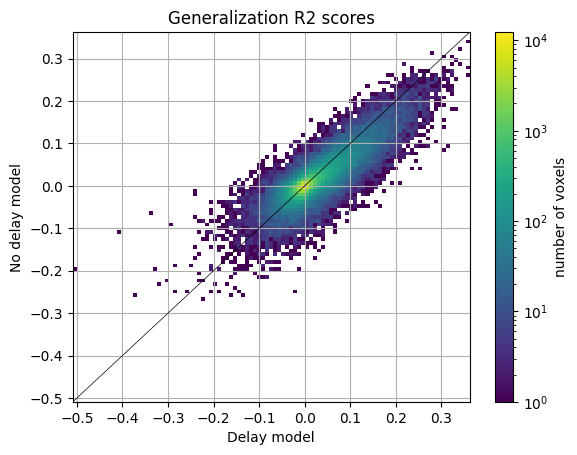

In [30]:
from voxelwise_tutorials.viz import plot_hist2d

scores_no_delay = np.load(os.path.join(RESULTS_DATA_DIR, subject_2,'scores_test_transform.npy'))
scores_delay = scores_test.cpu().numpy()
ax = plot_hist2d(scores_no_delay, scores_delay)
ax.set(title='Generalization R2 scores', ylabel='No delay model',
       xlabel='Delay model')
plt.show()

In [31]:
print("Max no delay:", np.max(scores_no_delay))
print("Max delay:", np.max(scores_delay))
print("Min no delay:", np.min(scores_no_delay))
print("Min delay:", np.min(scores_delay))


Max no delay: 0.36237340866641077
Max delay: 0.3406194506802094
Min no delay: -0.5087542386087904
Min delay: -0.2689531036992556


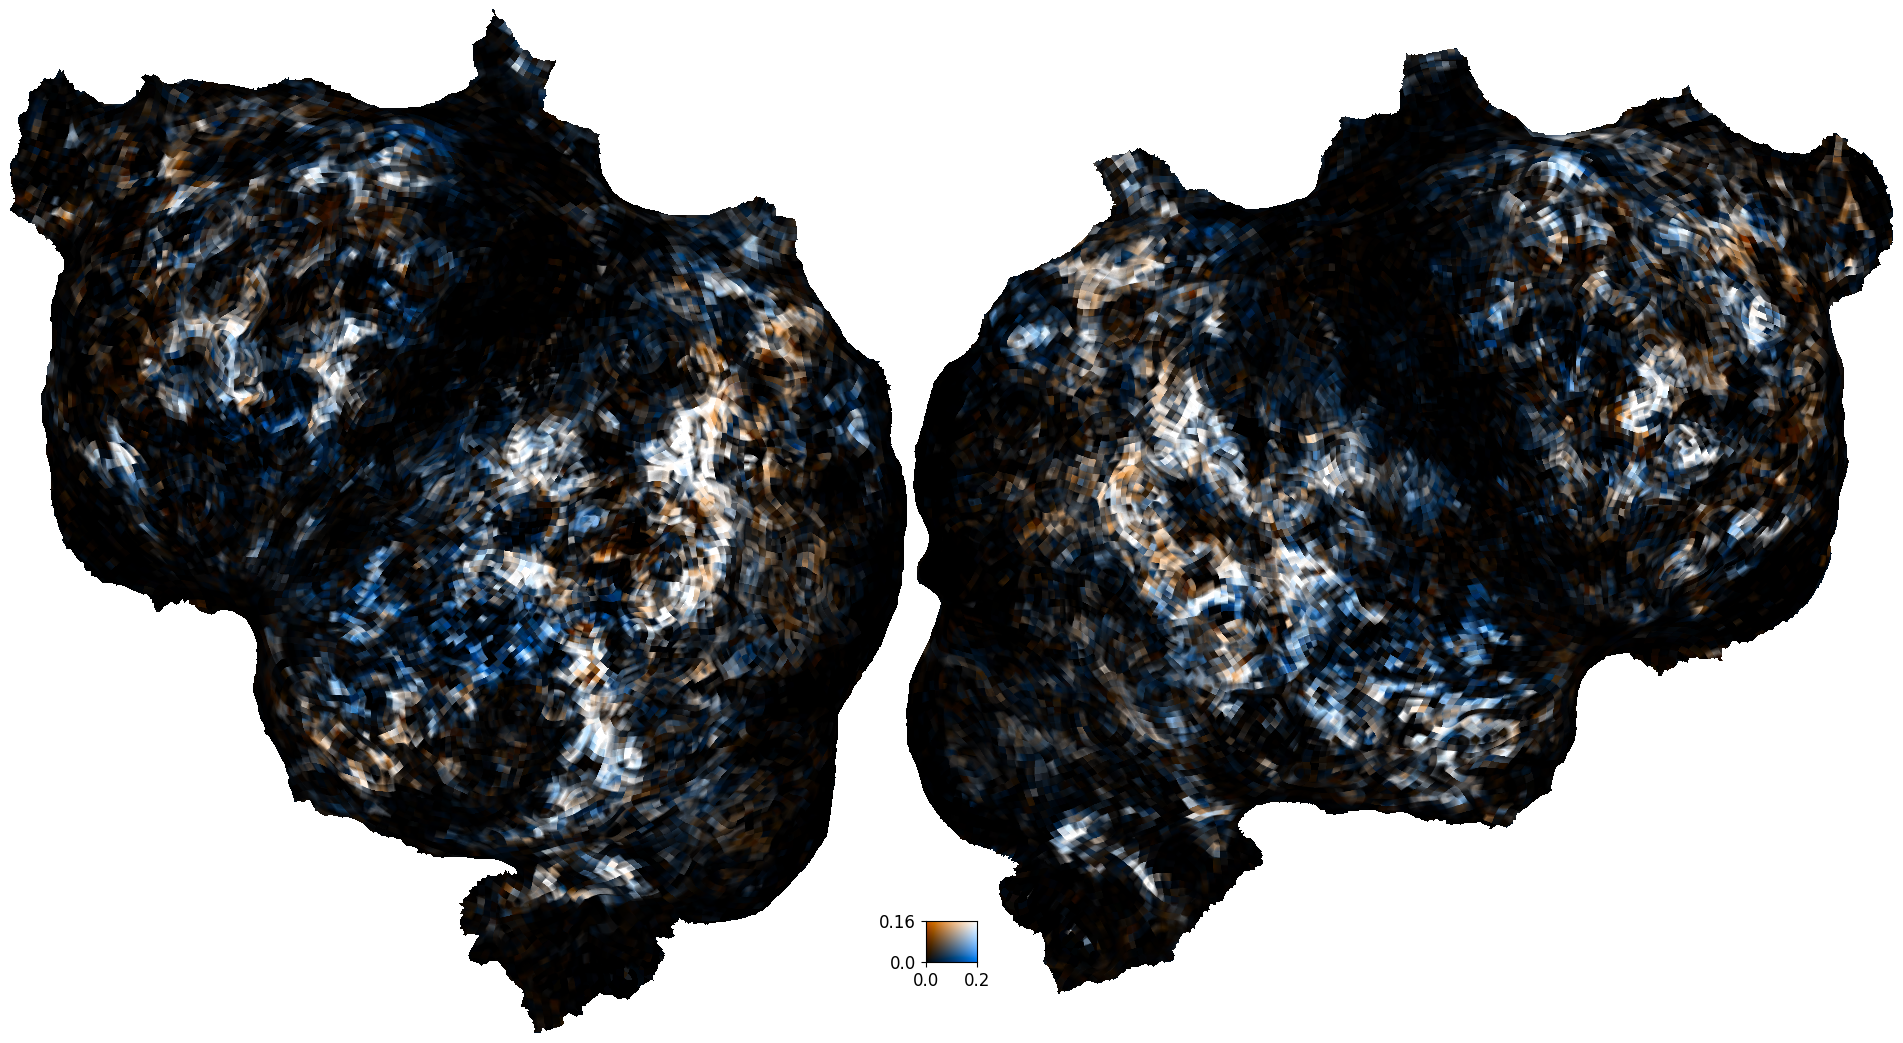

In [32]:
# This creates a 2D Volume object for both of our test datasets for the given
# subject and transform

# You can alter the minimum and maximum values shown on the colorbar and this
# can be done separately for the two different datasets
vol_data = cortex.Volume2D(scores_no_delay, scores_delay, subject, xfm,
                           #cmap="GreenWhiteBlue_2D",
                           vmin=0,vmin2=0
                           )
cortex.quickshow(vol_data, with_rois=False )# with_colorbar=False,
plt.show()